In [2]:
#! pip -q install textblob
from textblob import TextBlob

In [3]:
def sentiment_analysis(tweet):
    analysis = TextBlob(tweet)
    if analysis.sentiment.polarity > 0:
        sentiment = "Positive"
    elif analysis.sentiment.polarity < 0:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    return sentiment

In [6]:
tweet = "This is a great day, I love the sunny weather"
sentiment_result = sentiment_analysis(tweet)
print(f"Sentiment result is {sentiment_result}")

Sentiment result is Positive


In [6]:
text = "Textblob is the best Python library for sentiment analysis"
blob = TextBlob(text)
subjective = blob.sentiment.subjectivity
print(f"Subjective: {subjective}")

Subjective: 0.3


In [15]:
#! pip install transformers pysentimiento tf_keras

from transformers import pipeline

analizador = pipeline(
    "sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis"
)
tweet_es = "Este es un maravilloso día, voy a disfrutar de mi fin de semana"
print(analizador(tweet_es))

Device set to use cpu


[{'label': 'POS', 'score': 0.9716461300849915}]


In [17]:
analizador = pipeline(
    "sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis"
)
tweet_es = "El hotel es desagradable, tenía cucarachas en el baño."
print(analizador(tweet_es))

Device set to use cpu


[{'label': 'NEG', 'score': 0.9762331247329712}]


In [19]:
analizador = pipeline(
    "sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis"
)
tweet_es = "Es otro día en la universidad, voy a reunirme con mis compañeros"
print(analizador(tweet_es))

Device set to use cpu


[{'label': 'NEU', 'score': 0.8453606367111206}]


In [20]:
etiquetas = {"POS": "Positivo 😊", "NEG": "Negativo 😠", "NEU": "Neutral 😐"}

texto = "No me gustó el servicio, fue muy lento"
res = analizador(texto)[0]

print(f"Texto: {texto}")
print(f"Sentimiento: {etiquetas[res['label']]} (confianza: {res['score']:.2%})")

Texto: No me gustó el servicio, fue muy lento
Sentimiento: Negativo 😠 (confianza: 96.34%)


Device set to use cpu
/tmp/ipykernel_44156/2934673869.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), palette="viridis")
/tmp/ipykernel_44156/2934673869.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), palette="viridis")


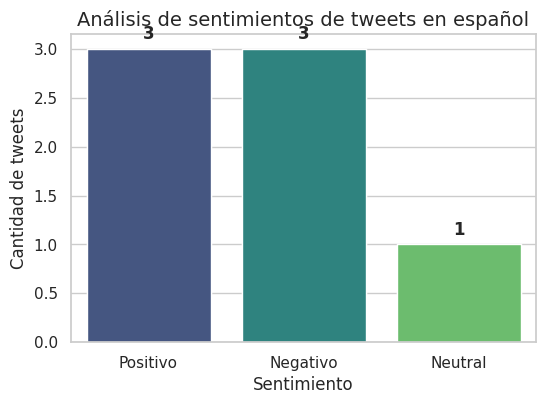

In [ ]:
#! pip install seaborn

from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el analizador de sentimientos en español
analizador = pipeline(
    "sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis"
)

# Lista de tweets o frases
tweets = [
    "Qué día tan horrible, todo salió mal",
    "Me siento bien, las cosas van mejorando",
    "No está mal, pero podría ser mejor",
    "Amo pasar tiempo con mis amigos",
    "Estoy muy enojado por el mal servicio",
    "El clima está regular hoy",
    "¡Qué gran noticia! Estoy muy feliz",
]

# Analizar sentimientos
resultados = analizador(tweets)

# Convertir resultados a una lista de etiquetas
etiquetas = [r["label"] for r in resultados]

# Contar ocurrencias de cada sentimiento
conteo = {
    "Positivo": etiquetas.count("POS"),
    "Negativo": etiquetas.count("NEG"),
    "Neutral": etiquetas.count("NEU"),
}

# Crear el gráfico
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), palette="viridis")

plt.title("Análisis de sentimientos de tweets en español", fontsize=14)
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de tweets")

ax = sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), palette="viridis")
for i, v in enumerate(conteo.values()):
    ax.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
plt.show()